### 1. Import thư viện 

In [2]:
import pandas as pd
import numpy as np
import joblib
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Sentence Transformers để tạo embeddings
from sentence_transformers import SentenceTransformer

# Scikit-learn cho mô hình và đánh giá
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import os


### 2. Tải và khám phá dữ liệu 

In [53]:
try:
    df = pd.read_csv('data/spam_dataset.csv', nrows=9000)
    print("Tải dữ liệu thành công!")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'data/raw_data.csv'.")
    print("Hãy chắc chắn rằng bạn đã tạo thư mục 'data' và đặt tệp dữ liệu vào đó.")

df.head()

Tải dữ liệu thành công!


,message_content,is_spam
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0
1,"Congratulations, you've won a prize! Call us n...",1
2,You have been pre-approved for a credit card w...,1
3,"Limited time offer, act now! Only a few spots ...",1
4,Your loan has been approved! Transfer funds to...,1


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   message_content  1000 non-null   object
 1   is_spam          1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [55]:
df['is_spam'].value_counts()


is_spam
0    500
1    500
Name: count, dtype: int64

### 3. Tiền xử lý dữ liệu 

In [56]:

# Xóa các dòng có giá trị thiếu (nếu có)
df.dropna(inplace=True)

# Chọn các cột cần thiết
data = df[['message_content', 'is_spam']]

print("Dữ liệu sau khi xử lý:")
data.head()


Dữ liệu sau khi xử lý:


,message_content,is_spam
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0
1,"Congratulations, you've won a prize! Call us n...",1
2,You have been pre-approved for a credit card w...,1
3,"Limited time offer, act now! Only a few spots ...",1
4,Your loan has been approved! Transfer funds to...,1


### 4. Tạo đặc trưng với SENTENCE TRANSFORMERS

In [57]:
# Sử dụng mô hình `all-MiniLM-L6-v2` đã được huấn luyện trước 
model_name = 'all-MiniLM-L6-v2'
embedding_model = SentenceTransformer(model_name)

In [58]:
# Tạo embeddings cho tất cả các tin nhắn
print("Bắt đầu tạo embeddings cho dữ liệu...")
corpus = data['message_content'].tolist()

# Sử dụng tqdm để theo dõi tiến trình
embeddings = embedding_model.encode(corpus, show_progress_bar=True)
# Tự động chia dữ liệu thành batch nhỏ 

print(f"Đã tạo xong embeddings. Kích thước của mảng embeddings: {embeddings.shape}")


Bắt đầu tạo embeddings cho dữ liệu...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Đã tạo xong embeddings. Kích thước của mảng embeddings: (1000, 384)


In [59]:
### save embeddings
joblib.dump(embeddings, 'data/embeding_spam_dataset.pkl')

['data/embeding_spam_dataset.pkl']

In [61]:
# lây embeddings từ file đã lưu
embeddings = joblib.load('data/embeding_spam_dataset.pkl')
# Gán X (features) và y (target)
X = embeddings
y = data['is_spam'].values

In [62]:
print("Kích thước của X:", X.shape)
print("Kích thước của y:", y.shape)

Kích thước của X: (1000, 384)
Kích thước của y: (1000,)


### 5. Xây dựng mô hình phân loại 

In [63]:
# Class Feed Forward Neural Network với Residual Connection
class FeedForwardSpamClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim1: int, hidden_dim2: int, output_dim: int):
        super(FeedForwardSpamClassifier, self).__init__()
        
        # Do đó, `hidden_dim1` phải bằng `input_dim`.
        if input_dim != hidden_dim1:
            raise ValueError(f"Để sử dụng Residual Connection, input_dim ({input_dim}) "
                             f"phải bằng hidden_dim1 ({hidden_dim1}).")

        # Khối Feed-Forward đầu tiên, nơi chúng ta sẽ áp dụng residual connection
        self.feed_forward_block = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.Mish(),
            nn.Linear(hidden_dim1, hidden_dim1),
        )
        
        # Khối MLP 
        self.second_block = nn.Sequential(
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.Mish(),
            nn.Linear(hidden_dim2, hidden_dim2),
        )

        # Lớp output để ra quyết định
        self.output_layer = nn.Linear(hidden_dim2, output_dim)
        
        # Lớp chuẩn hóa (Layer Normalization) có thể giúp ổn định việc training với residual connections
        self.layer_norm = nn.LayerNorm(hidden_dim1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Lưu lại giá trị đầu vào ban đầu cho residual connection
        residual = x 
        
        # Dữ liệu đi qua khối feed-forward đầu tiên
        out = self.feed_forward_block(x)
        out = out + residual
        out = self.layer_norm(out) # Áp dụng LayerNorm để ổn định
        
        # Tiếp tục đi qua khối thứ hai
        out = self.second_block(out)
        
        # Lớp đầu ra
        out = self.output_layer(out)
        return out

### 6. Chia dữ liệu, huấn luyện và tối ưu hóa mô hình 

In [64]:
# Chia dữ liệu thành tập train và test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Chuyển đổi dữ liệu sang dạng PyTorch Tensor
# (Giữ nguyên code từ trước)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Tạo DataLoader để quản lý batch
# (Giữ nguyên code từ trước)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

In [65]:
# --- THAY ĐỔI KHI KHỞI TẠO MODEL ---
INPUT_DIM = X_train.shape[1]
HIDDEN_DIM_1 = INPUT_DIM
HIDDEN_DIM_2 = 128
OUTPUT_DIM = 1
LEARNING_RATE = 0.001
EPOCHS = 35 

# TÍNH TOÁN TRỌNG SỐ CHO LỚP "SPAM" (LỚP DƯƠNG)
# Đếm số lượng mẫu trong tập train
num_ham = np.sum(y_train == 0)
num_spam = np.sum(y_train == 1)
# Tính trọng số: số mẫu âm / số mẫu dương
pos_weight_value = num_ham / num_spam 
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32)

print(f"Tỷ lệ Ham/Spam trong tập train: {num_ham}/{num_spam}")
print(f"Trọng số cho lớp Spam (pos_weight): {pos_weight_value:.2f}")


model = FeedForwardSpamClassifier(
    input_dim=INPUT_DIM, 
    hidden_dim1=HIDDEN_DIM_1, 
    hidden_dim2=HIDDEN_DIM_2,
    output_dim=OUTPUT_DIM
)

# THÊM `pos_weight` VÀO HÀM LOSS
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


Tỷ lệ Ham/Spam trong tập train: 400/400
Trọng số cho lớp Spam (pos_weight): 1.00


In [66]:
print("\nBắt đầu huấn luyện mô hình (có Residual Connection)...")
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}')

print("Huấn luyện hoàn tất!")


Bắt đầu huấn luyện mô hình (có Residual Connection)...
Epoch [5/35], Loss: 0.0000
Epoch [10/35], Loss: 0.0000
Epoch [15/35], Loss: 0.0000
Epoch [20/35], Loss: 0.0000
Epoch [25/35], Loss: 0.0000
Epoch [30/35], Loss: 0.0000
Epoch [35/35], Loss: 0.0000
Huấn luyện hoàn tất!


### 7. Đánh giá mô hình 

In [67]:
print("\nĐánh giá mô hình trên tập test...")
model.eval()
with torch.no_grad():
    y_predicted_logits = model(X_test_tensor)
    y_predicted_prob = torch.sigmoid(y_predicted_logits)
    y_predicted_labels = (y_predicted_prob > 0.4).int()

y_predicted_labels = y_predicted_labels.cpu().numpy()


Đánh giá mô hình trên tập test...



Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

         Ham       1.00      1.00      1.00       100
        Spam       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



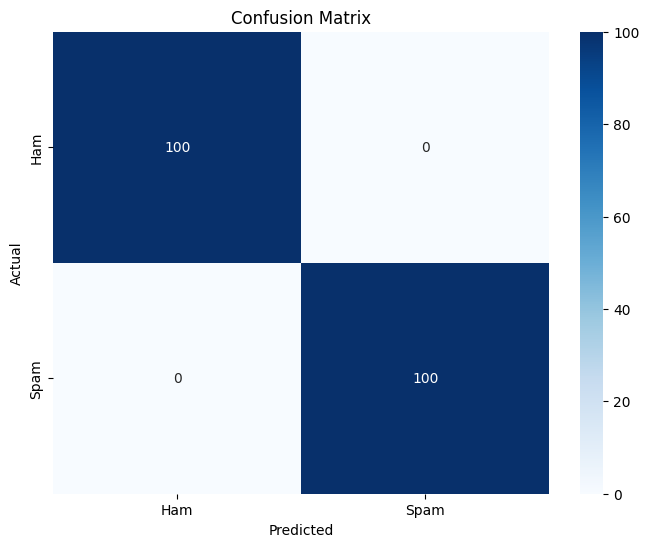

In [68]:
print(f"\nAccuracy: {accuracy_score(y_test, y_predicted_labels):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_predicted_labels, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### 7. Lưu mô hình tốt nhất 

In [69]:
MODEL_PATH = 'checkpoints/ff_spam_classifier_model_Spam_data.pth' # Tên file mới
torch.save(model.state_dict(), MODEL_PATH)
print(f"\nMô hình đã được lưu tại: {MODEL_PATH}")


Mô hình đã được lưu tại: checkpoints/ff_spam_classifier_model_Spam_data.pth


### 8. Sử dụng mô hình đã lưu 

In [70]:
# --- THAY ĐỔI KHI TẢI MODEL ---
# Tải lại mô hình để kiểm tra
loaded_model = FeedForwardSpamClassifier(
    input_dim=INPUT_DIM, 
    hidden_dim1=HIDDEN_DIM_1, 
    hidden_dim2=HIDDEN_DIM_2,
    output_dim=OUTPUT_DIM
)
MODEL_PATH = 'checkpoints/ff_spam_classifier_model_test.pth' # Dùng đúng tên file đã lưu
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

print("\nMô hình kiến trúc mới đã được tải lại và sẵn sàng để dự đoán.")

# Hàm dự đoán cho một tin nhắn mới (không thay đổi)
def predict_spam(message: str, embedding_model, classification_model):
    message_embedding = embedding_model.encode(message, convert_to_tensor=True)
    message_embedding = message_embedding.unsqueeze(0) 

    with torch.no_grad():
        logit = classification_model(message_embedding)
        prob = torch.sigmoid(logit)
        prediction = (prob > 0.5).int().item()

    return "Spam" if prediction == 1 else "Ham"

# Thử nghiệm với vài tin nhắn
test_message_1 = "Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/12345 to claim now."
test_message_2 = "Hey, are we still on for dinner tonight at 7pm? Let me know."
test_message_3 = "This is a reminder for your appointment tomorrow at 10am."
test_message_4 = "Get paid to work from home! Click here to learn more: http://spam-link.com"
test_message_5 = "Hi mom, I'll be home late for dinner tonight. Don't wait up for me."

print(f"\nTin nhắn 1: '{test_message_1}'")
print(f"Dự đoán: {predict_spam(test_message_1, embedding_model, loaded_model)}")

print(f"\nTin nhắn 2: '{test_message_2}'")
print(f"Dự đoán: {predict_spam(test_message_2, embedding_model, loaded_model)}")

print(f"\nTin nhắn 3: '{test_message_3}'")
print(f"Dự đoán: {predict_spam(test_message_3, embedding_model, loaded_model)}")

print(f"\nTin nhắn 4: '{test_message_4}'")
print(f"Dự đoán: {predict_spam(test_message_4, embedding_model, loaded_model)}")

print(f"\nTin nhắn 5: '{test_message_5}'")
print(f"Dự đoán: {predict_spam(test_message_5, embedding_model, loaded_model)}")


Mô hình kiến trúc mới đã được tải lại và sẵn sàng để dự đoán.

Tin nhắn 1: 'Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/12345 to claim now.'
Dự đoán: Spam

Tin nhắn 2: 'Hey, are we still on for dinner tonight at 7pm? Let me know.'
Dự đoán: Ham

Tin nhắn 3: 'This is a reminder for your appointment tomorrow at 10am.'
Dự đoán: Ham

Tin nhắn 4: 'Get paid to work from home! Click here to learn more: http://spam-link.com'
Dự đoán: Spam

Tin nhắn 5: 'Hi mom, I'll be home late for dinner tonight. Don't wait up for me.'
Dự đoán: Ham
